C:\Users\Admin\AppData\Local\Temp\ipykernel_5096\4029881510.py:33: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


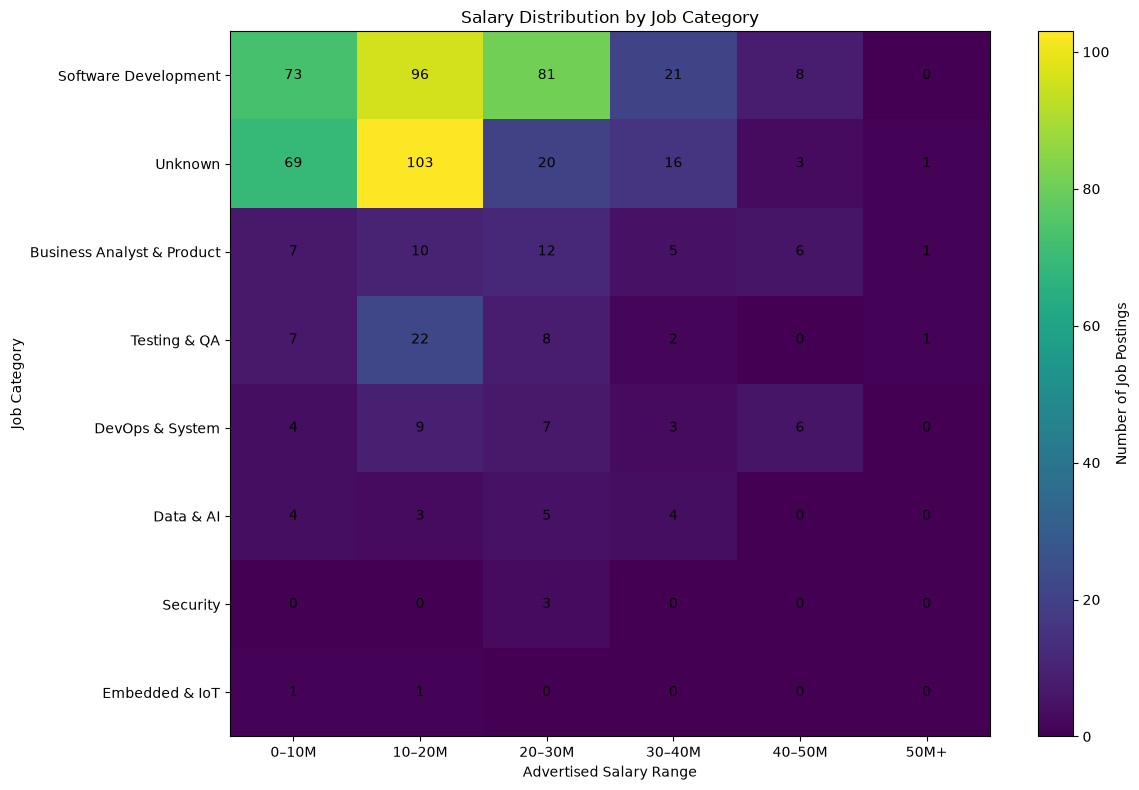

In [2]:
import mysql.connector
import pandas as pd
import matplotlib.pyplot as plt


conn = mysql.connector.connect(
    host="localhost",
    port=3306,
    user="mysql",
    password="mysql",
    database="jobs_db"
)

query = """
SELECT
    job_category,
    salary_unit,
    min_salary,
    max_salary
FROM jobs
WHERE job_category IS NOT NULL;
"""

df = pd.read_sql(query, conn)

conn.close()

USD_TO_VND = 23.757

df["min_salary_vnd"] = df["min_salary"]
df["max_salary_vnd"] = df["max_salary"]

usd_mask = df["salary_unit"].eq("USD")

df.loc[usd_mask, "min_salary_vnd"] *= USD_TO_VND
df.loc[usd_mask, "max_salary_vnd"] *= USD_TO_VND


df["salary_mid"] = (
    df["min_salary_vnd"] +
    df["max_salary_vnd"]
) / 2


df = df.dropna(
    subset=["min_salary_vnd", "max_salary_vnd"]
)


bins = [
    0,
    10_000_000,
    20_000_000,
    30_000_000,
    40_000_000,
    50_000_000,
    float("inf")
]

labels = [
    "0–10M",
    "10–20M",
    "20–30M",
    "30–40M",
    "40–50M",
    "50M+"
]

df["salary_bucket"] = pd.cut(
    df["salary_mid"],
    bins=bins,
    labels=labels,
    right=False
)


heatmap_data = pd.crosstab(
    df["job_category"],
    df["salary_bucket"]
)

heatmap_data = heatmap_data.reindex(
    columns=labels,
    fill_value=0
)

heatmap_data = heatmap_data.loc[
    heatmap_data.sum(axis=1)
    .sort_values(ascending=False)
    .index
]

fig, ax = plt.subplots(figsize=(12, 8))

image = ax.imshow(
    heatmap_data.values,
    aspect="auto"
)

ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels)

ax.set_yticks(range(len(heatmap_data.index)))
ax.set_yticklabels(heatmap_data.index)

ax.set_xlabel("Advertised Salary Range")
ax.set_ylabel("Job Category")

ax.set_title(
    "Salary Distribution by Job Category"
)


for i in range(heatmap_data.shape[0]):
    for j in range(heatmap_data.shape[1]):

        value = heatmap_data.iloc[i, j]

        ax.text(
            j,
            i,
            value,
            ha="center",
            va="center"
        )

colorbar = plt.colorbar(
    image,
    ax=ax
)

colorbar.set_label(
    "Number of Job Postings"
)

plt.tight_layout()
plt.show()

Đang kết nối CSDL và lấy dữ liệu...
Tổng số bản ghi thu thập: 2,142
            city  job_count
     Ha Noi city       1303
Ho Chi Minh city        629
    Da Nang city         79
      Binh Duong         19
      Nước Ngoài         16
Thua Thien - Hue         16
    Can Tho city         10
       Toàn Quốc          9
         Nghe An          8
  Hai Phong city          6
        Dong Nai          6
       Hai Duong          5
        Bac Ninh          5
       Dong Thap          5
       Thanh Hoa          4
       Khanh Hoa          4
         Long An          3
          Ha Nam          2
         Gia Lai          1
       Bac Giang          1
        An Giang          1
       Binh Dinh          1
         Ben Tre          1
         Ha Tinh          1
        Lam Dong          1
        Hoa Binh          1
        Hung Yen          1
       Thai Binh          1
        Tay Ninh          1
      Tien Giang          1
       Vinh Phuc          1


C:\Users\Admin\AppData\Local\Temp\ipykernel_5096\3366819350.py:25: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


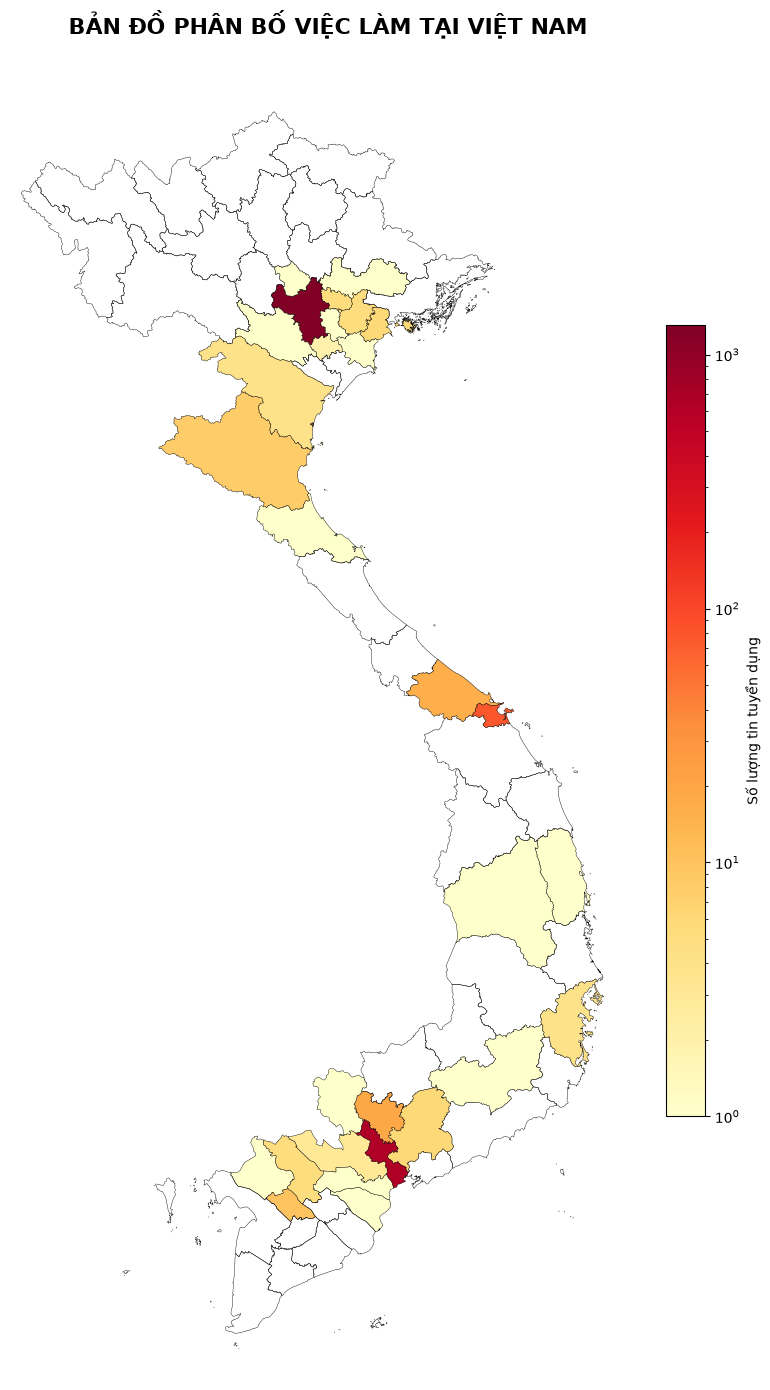

In [ ]:
import geopandas as gpd
import matplotlib.colors as colors
import matplotlib.pyplot as plt
import mysql.connector
import pandas as pd


def get_job_data():
    conn = mysql.connector.connect(
        host="localhost",
        port=3306,
        user="mysql",
        password="mysql",
        database="jobs_db",
    )

    query = """
        SELECT city
        FROM jobs
        WHERE city IS NOT NULL
          AND city <> ''
    """

    df = pd.read_sql(query, conn)
    conn.close()

    return df


def normalize_city_name(df):
    df = df.copy()

    city_mapping = {
        "Hà Nội": "Ha Noi city",
        "Hồ Chí Minh": "Ho Chi Minh city",
        "Đồng Nai": "Dong Nai",
        "Tiền Giang": "Tien Giang",
        "Cần Thơ": "Can Tho city",
        "Đà Nẵng": "Da Nang city",
        "Thừa Thiên Huế": "Thua Thien - Hue",
        "Khánh Hoà": "Khanh Hoa",
        "Tây Ninh": "Tay Ninh",
        "Long An": "Long An",
        "Bình Dương": "Binh Duong",
        "Đồng Tháp": "Dong Thap",
        "Thanh Hoá": "Thanh Hoa",
        "Hưng Yên": "Hung Yen",
        "Hoà Bình": "Hoa Binh",
        "Bắc Giang": "Bac Giang",
        "Bắc Ninh": "Bac Ninh",
        "Hải Phòng": "Hai Phong city",
        "Bến Tre": "Ben Tre",
        "Hà Tĩnh": "Ha Tinh",
        "Nghệ An": "Nghe An",
        "Thái Bình": "Thai Binh",
        "Gia Lai": "Gia Lai",
        "Hà Nam": "Ha Nam",
        "Hải Dương": "Hai Duong",
        "An Giang": "An Giang",
        "Lâm Đồng": "Lam Dong",
        "Bình Định": "Binh Dinh",
        "Vĩnh Phúc": "Vinh Phuc",
    }

    extended_mapping = city_mapping.copy()
    extended_mapping.update(
        {
            "Ha Noi": "Ha Noi city",
            "Ho Chi Minh": "Ho Chi Minh city",
            "Da Nang": "Da Nang city",
            "Can Tho": "Can Tho city",
            "Hai Phong": "Hai Phong city",
            "Thua Thien Hue": "Thua Thien - Hue",
        }
    )

    df["city"] = df["city"].replace(extended_mapping)
    return df

def count_jobs_by_city(df):
    job_counts = df.groupby("city").size().reset_index(name="job_count")
    return job_counts


def load_vietnam_map(geojson_path="vietnam_provinces.geojson"):
    vietnam = gpd.read_file(geojson_path)
    if vietnam.crs is None:
        vietnam.set_crs(epsg=4326, inplace=True)

    return vietnam



def merge_job_data(vietnam, job_counts):
    merged = vietnam.merge(
        job_counts, left_on="Name", right_on="city", how="left"
    )

    merged["job_count"] = merged["job_count"].fillna(0).astype(int)

    return merged

def plot_heatmap(vietnam):
    fig, ax = plt.subplots(figsize=(10, 14))


    max_val = vietnam["job_count"].max()

    vietnam.plot(
        column="job_count",
        ax=ax,
        cmap="YlOrRd", 
        legend=True,
        edgecolor="black",
        linewidth=0.3,
        norm=(
            colors.LogNorm(vmin=1, vmax=max_val) if max_val > 0 else None
        ),
        missing_kwds={
            "color": "#e0e0e0",
            "label": "Không có dữ liệu",
        },  
        legend_kwds={
            "label": "Số lượng tin tuyển dụng",
            "orientation": "vertical",
            "shrink": 0.6,
            "pad": 0.02,
        },
    )

    ax.set_title(
        "BẢN ĐỒ PHÂN BỐ VIỆC LÀM TẠI VIỆT NAM",
        fontsize=16,
        fontweight="bold",
        pad=20,
    )


    ax.axis("off")


    ax.set_xlim([102.0, 110.0])
    ax.set_ylim([8.0, 24.0])

    plt.tight_layout()
    plt.show()


def main():
    print("Đang kết nối CSDL và lấy dữ liệu...")
    df = get_job_data()
    print(f"Tổng số bản ghi thu thập: {len(df):,}")

    df = normalize_city_name(df)

    job_counts = count_jobs_by_city(df)

    print(
        job_counts.sort_values("job_count", ascending=False).to_string(
            index=False
        )
    )

    vietnam_map = load_vietnam_map("vietnam_provinces.geojson")
    vietnam_merged = merge_job_data(vietnam_map, job_counts)

    plot_heatmap(vietnam_merged)


if __name__ == "__main__":
    main()

True


C:\Users\Admin\AppData\Local\Temp\ipykernel_16092\1350802257.py:23: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


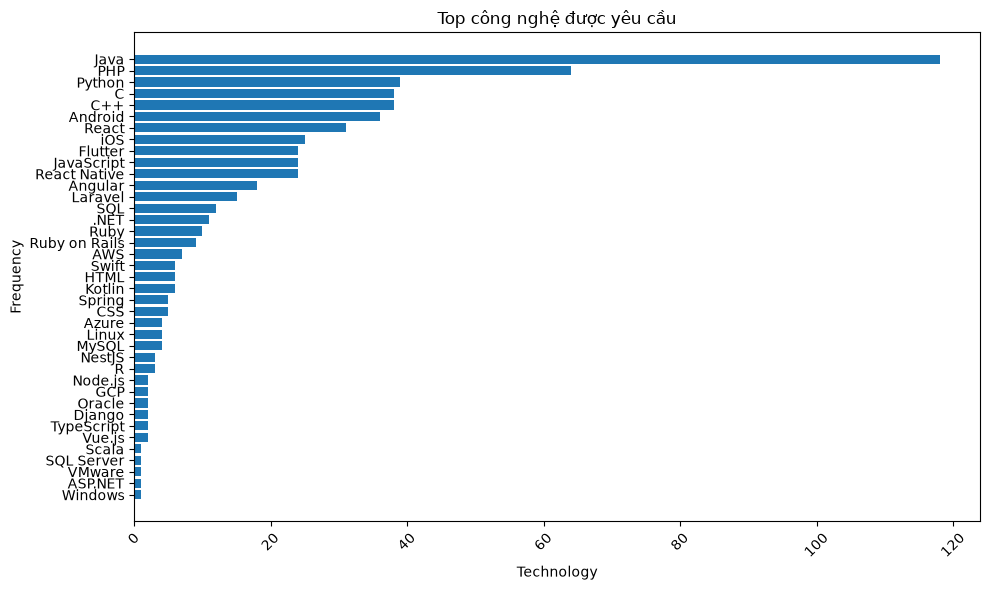

In [12]:
import matplotlib.pyplot as plt
from mysql import connector
import pandas as pd

conn = connector.connect(
    host="localhost",
    port=3306,
    user="mysql",
    password="mysql",
    database="jobs_db",
)

query = r"""
SELECT
    t.name,
    COUNT(DISTINCT j.job_title) AS frequency
FROM technologies t, jobs j
WHERE LOWER(j.job_title) REGEXP CONCAT('\\b', LOWER(t.name), '\\b')
GROUP BY t.name
ORDER BY frequency ASC;
"""
print(conn.is_connected())
df = pd.read_sql(query, conn)
conn.close()

plt.figure(figsize=(10, 6))

plt.barh(
    df["name"],
    df["frequency"]
)

plt.title("Top công nghệ được yêu cầu")
plt.xlabel("Technology")
plt.ylabel("Frequency")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()